In [ ]:
import cv2
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'ảnh gốc')

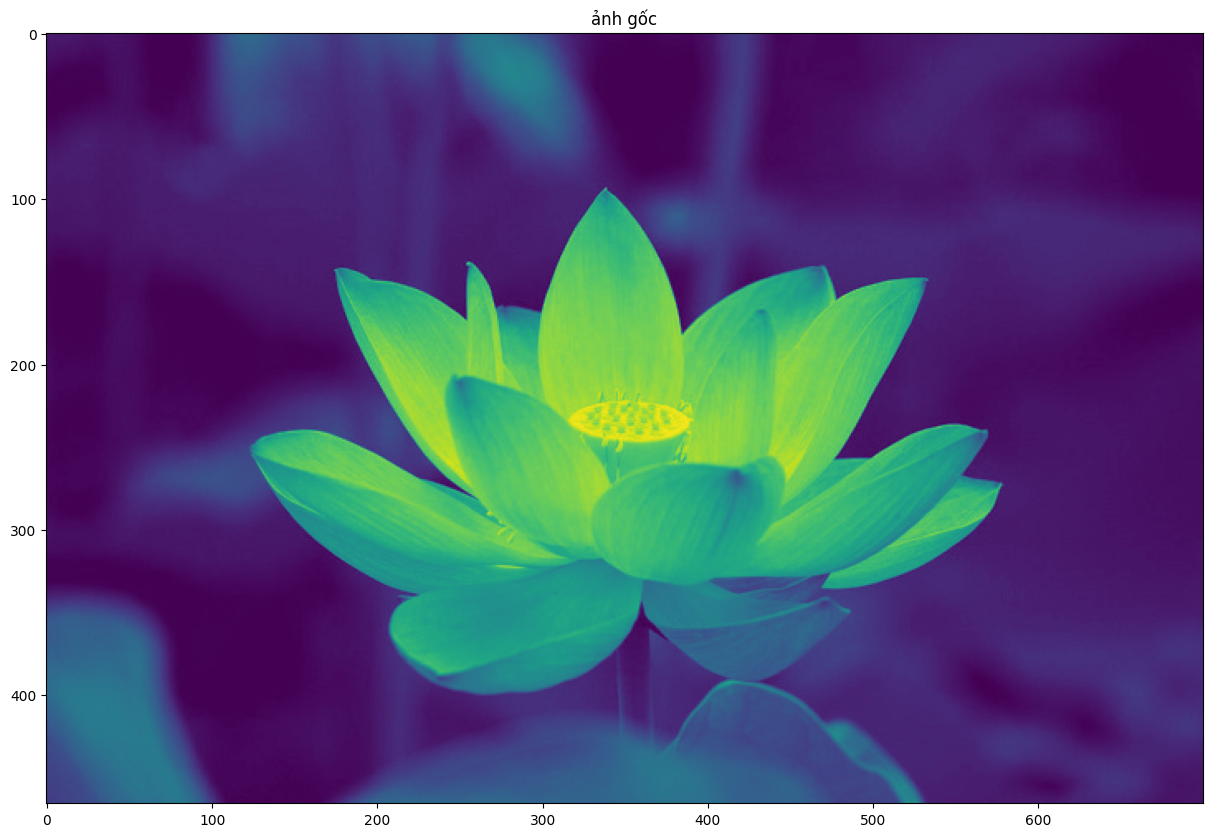

In [ ]:
# BÀI TẬP BIÊN CẠNH
img = cv2.imread('/content/hoasen.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(15, 10))
plt.imshow(gray)
plt.title('ảnh gốc')

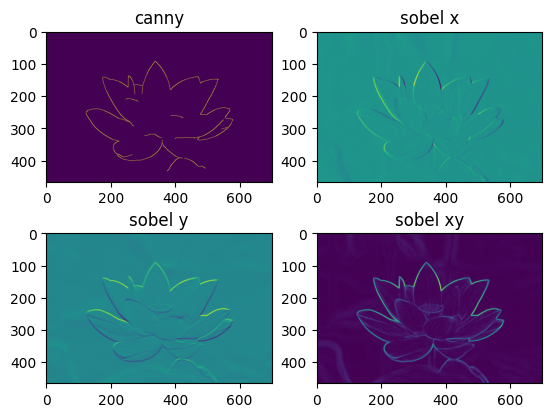

In [ ]:
# 2. Tìm cạnh bằng canny và sobel
# khử nhiễu bằng gaussian
khunhieu = cv2.GaussianBlur(gray, (5,5), 1, 1)

# tìm cạnh bằng canny
canny_edge = cv2.Canny(khunhieu, 100, 200)

# tìm cạnh bằng sobel
x = cv2.Sobel(khunhieu, cv2.CV_64F, 1, 0, ksize=3)
y = cv2.Sobel(khunhieu, cv2.CV_64F, 0, 1, ksize=3)
# xy = cv2.Sobel(khunhieu, cv2.CV_64F, 1, 1, ksize=3)
xy = cv2.magnitude(x, y)
plt.subplot(2,2,1)
plt.imshow(canny_edge)
plt.title('canny')

plt.subplot(2,2,2)
plt.imshow(x)
plt.title('sobel x')

plt.subplot(2,2,3)
plt.imshow(y)
plt.title('sobel y')

plt.subplot(2,2,4)
plt.imshow(xy)
plt.title('sobel xy')

plt.show()



In [ ]:
# 2. dung nonzero so sánh canny và sobel
# chuẩn hóa về binary
import numpy as np
xy = np.uint8(xy)
_, sobel_bin = cv2.threshold(xy, 50, 255, cv2.THRESH_BINARY)

can = cv2.countNonZero(canny_edge)
sob = cv2.countNonZero(sobel_bin)
print("canny: ", can)
print("sobel: ", sob)

canny:  2723
sobel:  13758


original canny:  2723
morphology canny:  2682


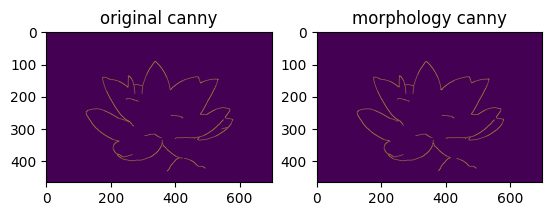

In [ ]:
# 3. dùng hình thái học để làm mịn ảnh
# dùng morphology
# kernel hình thái học
kernel = np.ones((3,3), np.uint8)
open = cv2.morphologyEx(khunhieu, cv2.MORPH_OPEN, kernel)
close = cv2.morphologyEx(open, cv2.MORPH_CLOSE, kernel)

mor_canny = cv2.Canny(close, 100, 200)
plt.subplot(2,2,1)
plt.imshow(canny_edge)
plt.title('original canny')

plt.subplot(2,2,2)
plt.imshow(mor_canny)
plt.title('morphology canny')

ori_can = cv2.countNonZero(canny_edge)
mor_can = cv2.countNonZero(mor_canny)
print("original canny: ", ori_can)
print("morphology canny: ", mor_can)

In [ ]:
# 4. dùng rgb tìm biên cạnh
r, g, b = cv2.split(img)


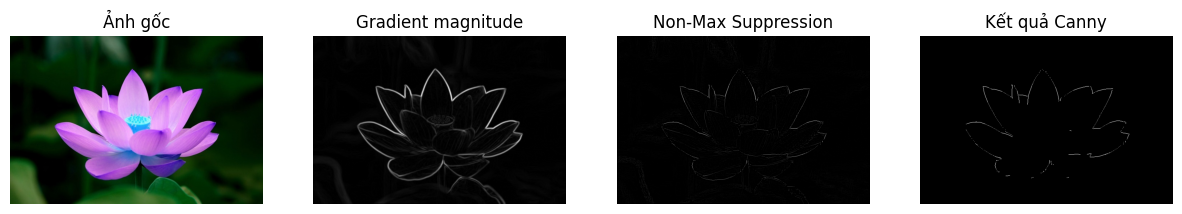

In [ ]:
# xây dựng lại giải thuật canny
# b1. noise reduction
# Convert to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray_img, (5, 5), 1.4)

# b2. finding intensity gradient of image
Gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.hypot(Gx, Gy)
magnitude = magnitude / magnitude.max() * 255
theta = np.arctan2(Gy, Gx)

# b3. non-maximum suppresion
def non_max_suppression(mag, angle):
    M, N = mag.shape
    Z = np.zeros((M,N), dtype=np.float32)
    angle = angle * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1,M-1):
        for j in range(1,N-1):
            q = 255
            r = 255

            # Xác định hướng
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = mag[i, j+1]
                r = mag[i, j-1]
            elif (22.5 <= angle[i,j] < 67.5):
                q = mag[i+1, j-1]
                r = mag[i-1, j+1]
            elif (67.5 <= angle[i,j] < 112.5):
                q = mag[i+1, j]
                r = mag[i-1, j]
            elif (112.5 <= angle[i,j] < 157.5):
                q = mag[i-1, j-1]
                r = mag[i+1, j+1]

            # Giữ lại điểm cực đại theo hướng gradient
            if (mag[i,j] >= q) and (mag[i,j] >= r):
                Z[i,j] = mag[i,j]
            else:
                Z[i,j] = 0
    return Z

nms = non_max_suppression(magnitude, theta)

# b4. hysteresis thresholding
def hysteresis_threshold(img, low, high):
    M, N = img.shape
    res = np.zeros((M, N), dtype=np.uint8)

    strong = 255
    weak = 75

    strong_i, strong_j = np.where(img >= high)
    weak_i, weak_j = np.where((img <= high) & (img >= low))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    # Liên kết biên yếu với biên mạnh
    for i in range(1, M-1):
        for j in range(1, N-1):
            if res[i,j] == weak:
                if ((res[i+1, j-1] == strong) or (res[i+1, j] == strong) or (res[i+1, j+1] == strong)
                    or (res[i, j-1] == strong) or (res[i, j+1] == strong)
                    or (res[i-1, j-1] == strong) or (res[i-1, j] == strong) or (res[i-1, j+1] == strong)):
                    res[i,j] = strong
                else:
                    res[i,j] = 0
    return res

edges = hysteresis_threshold(nms, low=50, high=100)

plt.figure(figsize=(15,6))
plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Gradient magnitude")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(nms, cmap='gray')
plt.title("Non-Max Suppression")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(edges, cmap='gray')
plt.title("Kết quả Canny")
plt.axis('off')
plt.show()

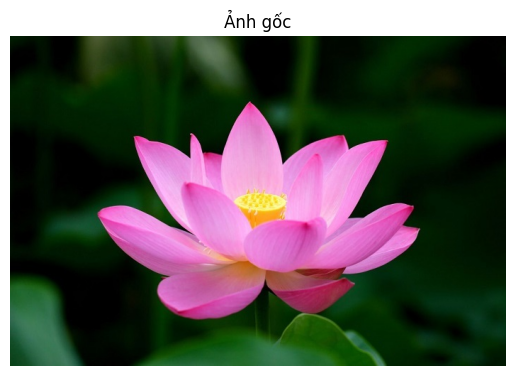

In [1]:
# BÀI TẬP
import cv2
from skimage.feature import hog, corner_harris, corner_peaks, BRIEF
from skimage import color
import matplotlib.pyplot as plt
import numpy as np

# 1. Đọc ảnh màu
img = cv2.imread('/content/hoasen.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Ảnh gốc")
plt.axis('off')
plt.show()

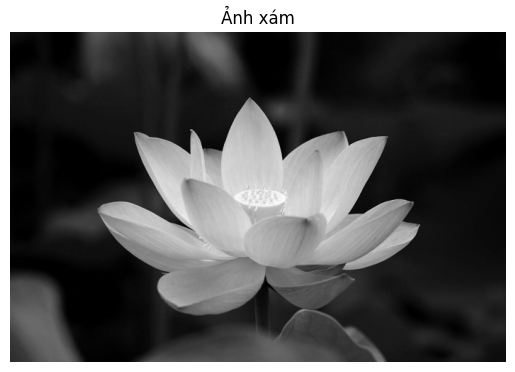

In [2]:
# 2. Chuyển ảnh sang xám
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img2, cmap='gray')
plt.title("Ảnh xám")
plt.axis('off')
plt.show()


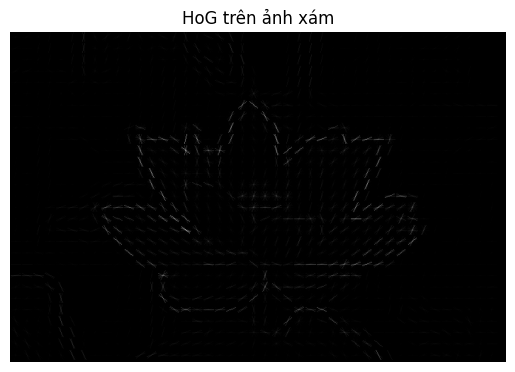

In [3]:
from skimage.feature import hog

# HoG feature
fd, hog_image = hog(img2, pixels_per_cell=(16,16), cells_per_block=(2,2),
                    visualize=True, channel_axis=None)
plt.imshow(hog_image, cmap='gray')
plt.title("HoG trên ảnh xám")
plt.axis('off')
plt.show()


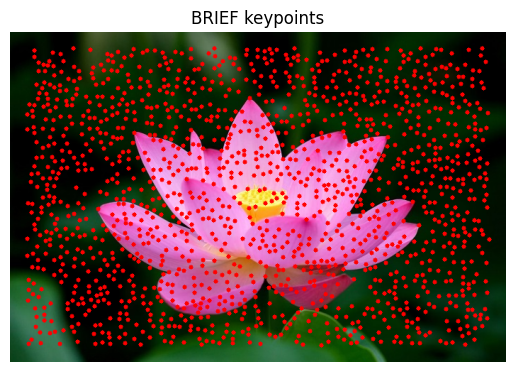

In [4]:
from skimage.feature import corner_peaks, corner_harris, BRIEF

# Tìm các điểm góc Harris trước
corners = corner_peaks(corner_harris(img2), min_distance=5)
brief = BRIEF()
brief.extract(img2, corners)
keypoints_brief = corners[brief.mask]


img_brief = img_rgb.copy()
for y,x in keypoints_brief:
    cv2.circle(img_brief, (x,y), 3, (255,0,0), -1)
plt.imshow(img_brief)
plt.title("BRIEF keypoints")
plt.axis('off')
plt.show()


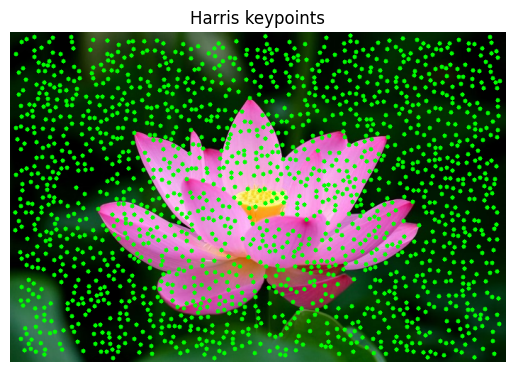

In [5]:
corners_harris = corner_peaks(corner_harris(img2), min_distance=5)
img_harris = img_rgb.copy()
for y,x in corners_harris:
    cv2.circle(img_harris, (x,y), 3, (0,255,0), -1)

plt.imshow(img_harris)
plt.title("Harris keypoints")
plt.axis('off')
plt.show()


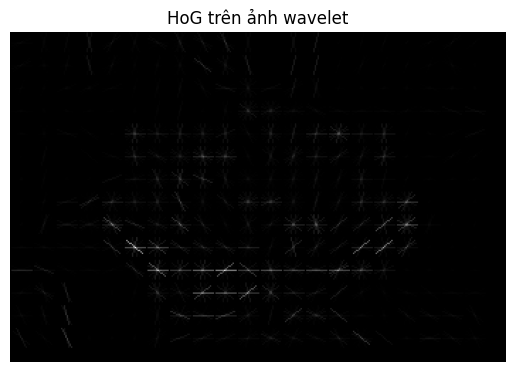

In [6]:
import pywt

# Khử nhiễu bằng wavelet
coeffs2 = pywt.dwt2(img2, 'haar')  # single level DWT
cA, (cH, cV, cD) = coeffs2
img_wavelet = cA.astype(np.uint8)

# HoG trên ảnh đã wavelet
fd_wavelet, hog_wavelet_img = hog(img_wavelet, pixels_per_cell=(16,16),
                                  cells_per_block=(2,2), visualize=True)
plt.imshow(hog_wavelet_img, cmap='gray')
plt.title("HoG trên ảnh wavelet")
plt.axis('off')
plt.show()


In [7]:
print("BRIEF on img2:", len(keypoints_brief))
print("Harris on img2:", len(corners_harris))


BRIEF on img2: 1500
Harris on img2: 1673


In [8]:
import cv2
import os

video_path = "/content/squat6.mp4"
frames_dir = "frames"
os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(os.path.join(frames_dir, f"frame_{count:04d}.jpg"), frame)
    count += 1

cap.release()
print(f"{count} frames extracted.")


300 frames extracted.


In [9]:
import numpy as np

# Khởi tạo background subtractor
mog = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=True)

# Tạo folder lưu kết quả
result_dir = "motion_result"
os.makedirs(result_dir, exist_ok=True)

# Lặp từng frame
frame_files = sorted(os.listdir(frames_dir))
motion_count = 0
motion_sizes = []

for file in frame_files:
    frame = cv2.imread(os.path.join(frames_dir, file))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Trừ nền
    fg_mask = mog.apply(gray)

    # Morphological operations để loại nhiễu
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_DILATE, kernel, iterations=2)

    # Tìm contours
    contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) < 100:  # bỏ vùng nhỏ
            continue
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)
        motion_count += 1
        motion_sizes.append(cv2.contourArea(cnt))

    # Lưu frame kết quả
    cv2.imwrite(os.path.join(result_dir, file), frame)

print(f"Total detected motions: {motion_count}")


Total detected motions: 5342


In [11]:
# Chia thành 3 loại: nhỏ (<500), vừa (500-2000), lớn (>2000)
small, medium, large = 0, 0, 0
for size in motion_sizes:
    if size < 500:
        small += 1
    elif size <= 2000:
        medium += 1
    else:
        large += 1

print(f"Small motions: {small}")
print(f"Medium motions: {medium}")
print(f"Large motions: {large}")


Small motions: 2940
Medium motions: 1418
Large motions: 984
